# Нейронная сеть прямого распространения (регрессор)


**Нейронная сеть прямого распространения** — это один из базовых типов искусственных нейронных сетей, в котором сигнал движется строго от входного слоя к выходному без циклов и обратных связей (в отличие от рекуррентных сетей). В режиме регрессора такая сеть предсказывает непрерывное числовое значение (или вектор значений) на основе входных признаков.

**Архитектура**

* Входной слой (число нейронов = числу признаков)
* 1+ скрытых слоёв (обычно с ReLU-активацией)
* Выходной слой: 1 нейрон без активации (линейный) — чтобы предсказывать любое вещественное число.

**Принцип**

Сигнал идёт строго слева направо (прямое распространение) без циклов

**Обучение**

Минимизация среднеквадратичной ошибки (MSE) или MAE с помощью обратного распространения ошибки (градиентный спуск, Adam и др.). Веса инициализируются случайно, затем корректируются.


# Используемые библиотеки

In [181]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
import re
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Описание и демонстрация датасета

Датасет **Home Value Insights** — это небольшой (1000 строк, 8 столбцов) и чистый набор данных для решения задачи регрессии (предсказания непрерывных величин). Он содержит 7 признаков дома (Square_Footage, Num_Bedrooms, Num_Bathrooms, Year_Built, Lot_Size, Garage_Size, Neighborhood_Quality) и целевую переменную — стоимость дома House_Price.

In [182]:
# Download latest version
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'home-value-insights' dataset.
Path to dataset files: /kaggle/input/home-value-insights


In [183]:
df = pd.read_csv(path + '/house_price_regression_dataset.csv')

TARGET = 'House_Price'

# таргет
y = df[TARGET]

# признаки (все столбцы кроме price)
X = df.drop(columns=[TARGET])

In [184]:
X.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.599637,0,5
1,4272,3,3,2016,4.753014,1,6
2,3592,1,2,2016,3.634823,0,9
3,966,1,2,1977,2.730667,1,8
4,4926,2,1,1993,4.699073,0,8


Разобьем выборку на обучение и тест с помощью `train_test_split`

# Препроцессинг датасета

In [185]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 54.8 KB


In [186]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=0.3)

X_train.shape, X_test.shape

((700, 7), (300, 7))

# Тепловая карта

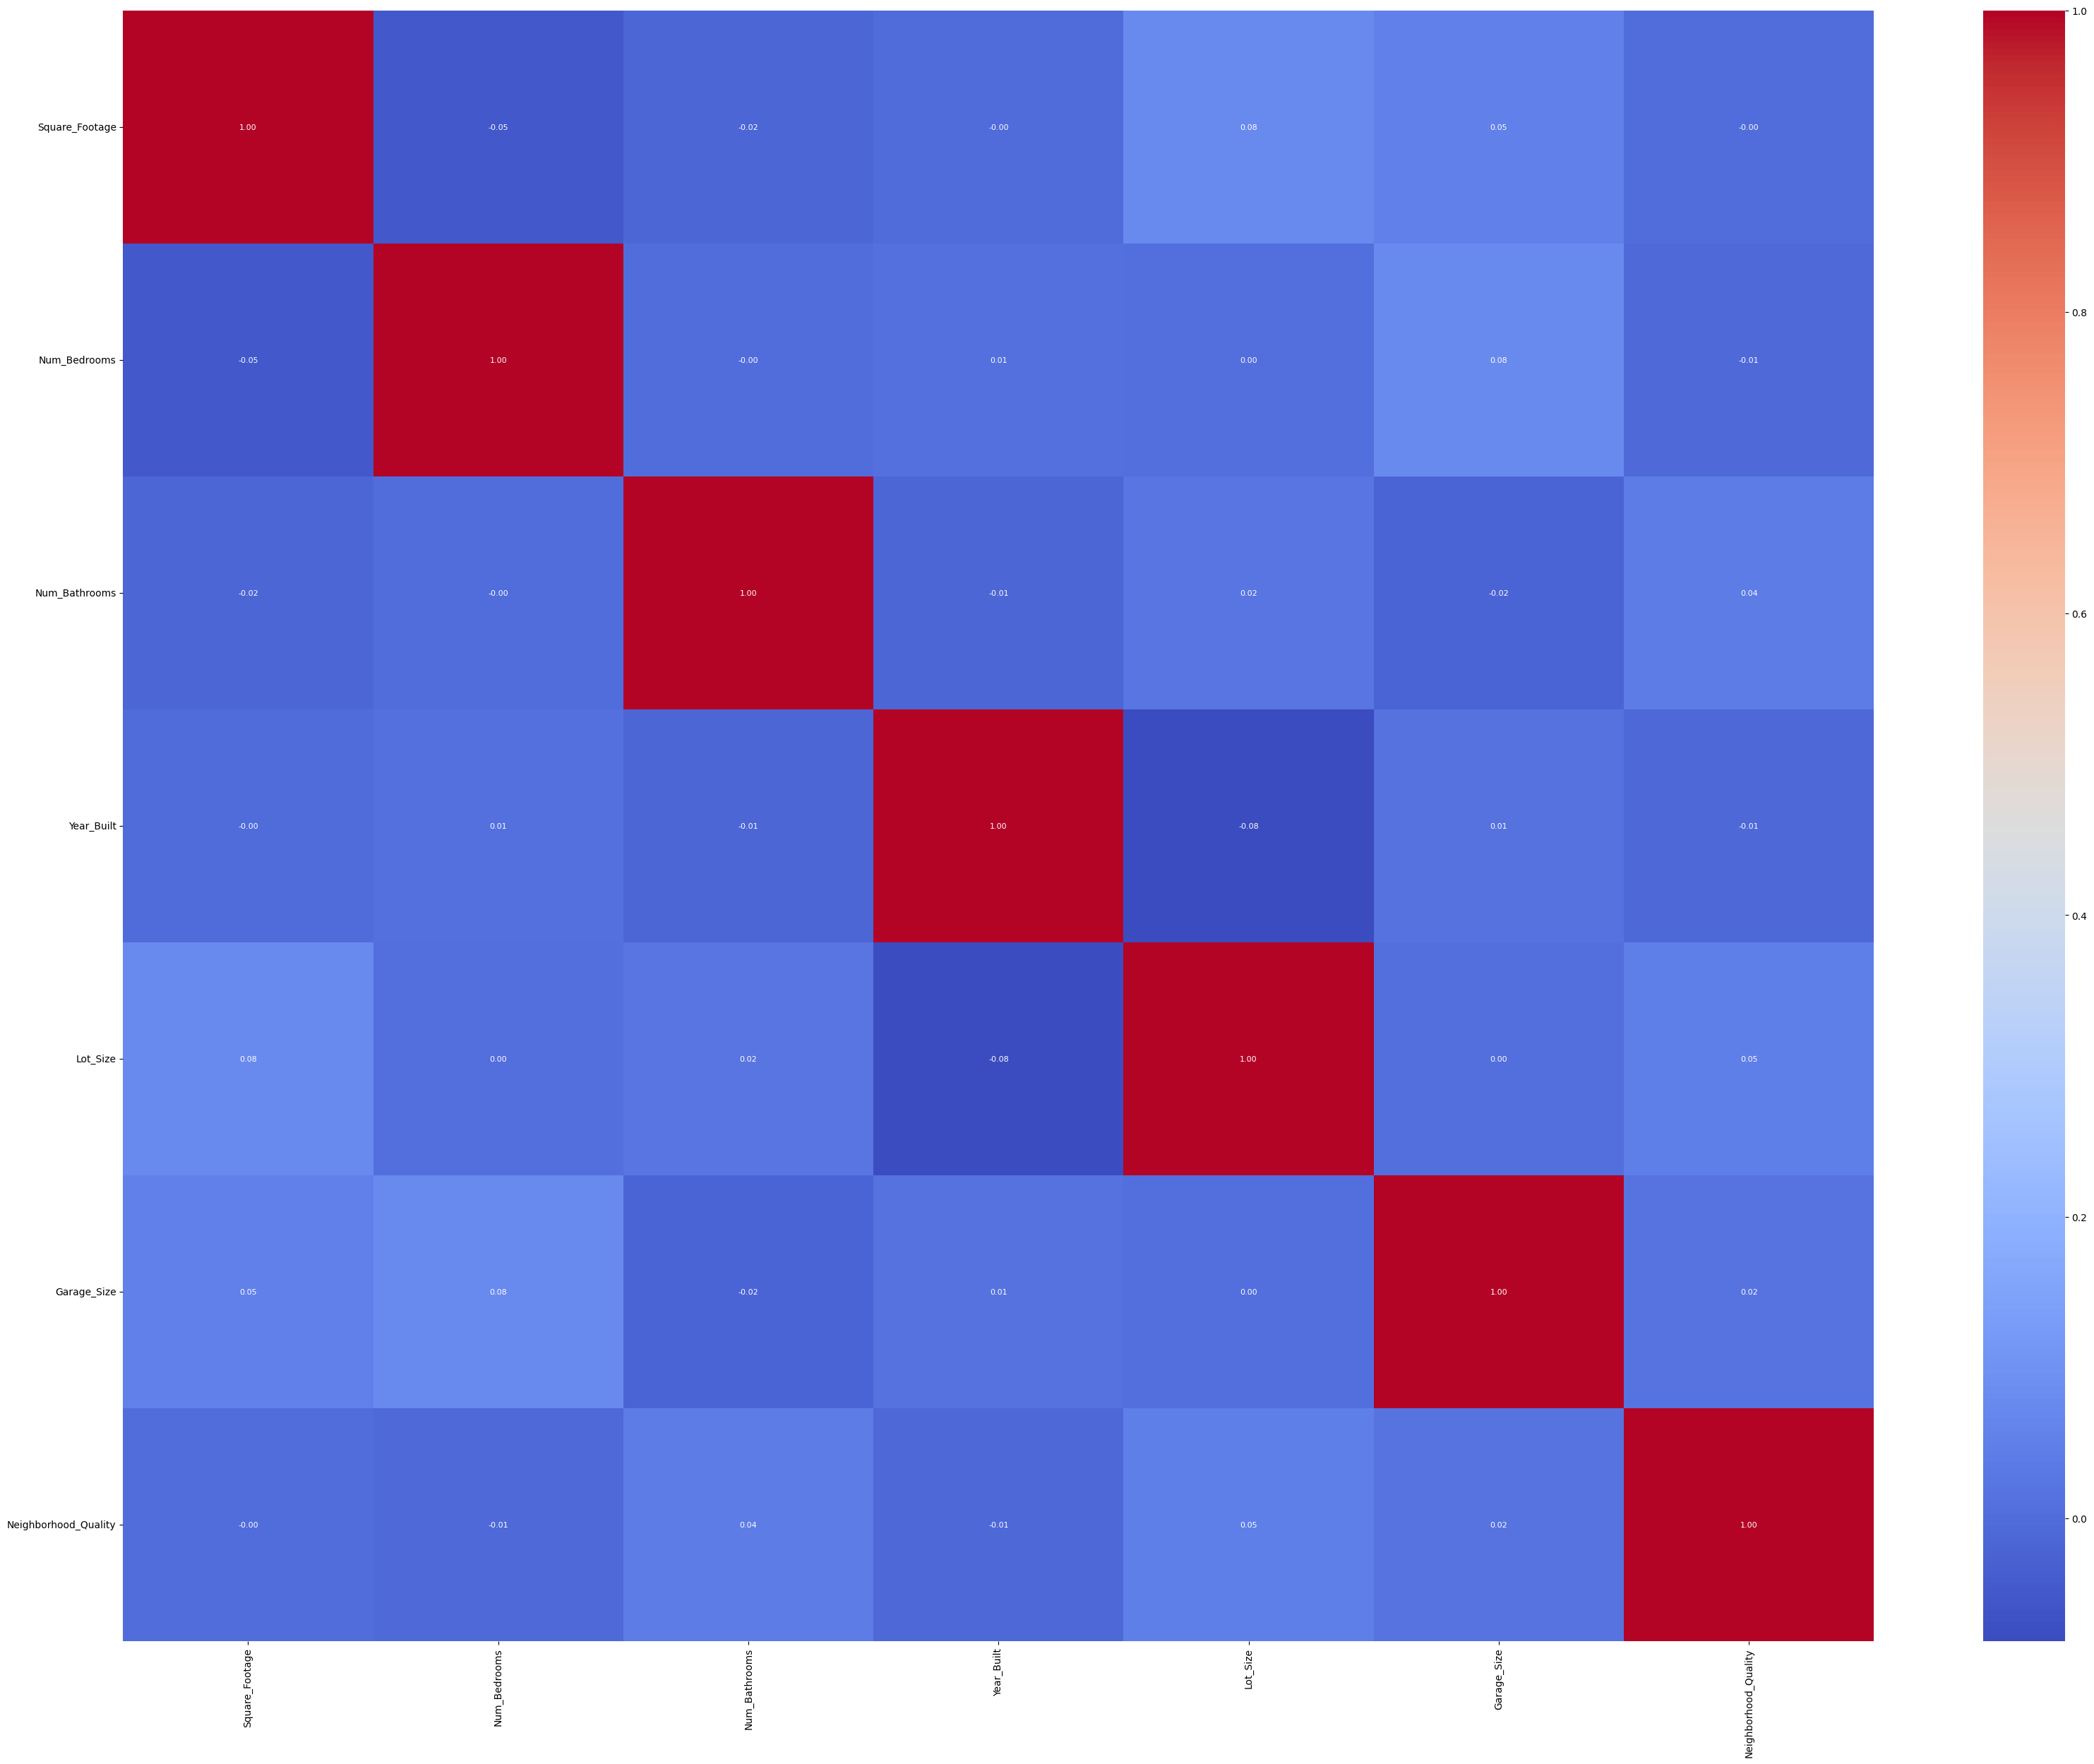

In [187]:

plt.figure(figsize=(40, 30))
sns.heatmap(
    X_train.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size":8},  # размер цифр
    xticklabels=X_train.columns,
    yticklabels=X_train.columns
)
plt.xticks(rotation=90)  # повернуть подписи по X
plt.yticks(rotation=0)   # по Y оставить горизонтально
plt.show()


# Обучение модели

Обучаем модель

In [188]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(8,4),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=5000,
        random_state=6769
    ))
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

model.fit(X_train, y_train)

TransformedTargetRegressor(regressor=Pipeline(steps=[('scaler',
                                                      StandardScaler()),
                                                     ('model',
                                                      MLPRegressor(hidden_layer_sizes=(8,
                                                                                       4),
                                                                   max_iter=5000,
                                                                   random_state=6769))]),
                           transformer=StandardScaler())

# Тестирование модели

Делаем предсказание

In [189]:
y_pred = model.predict(X_test)

## Обзор метрик

### MAE

**MAE (Mean Absolute Error)** — средняя абсолютная ошибка между истинными значениями и предсказаниями модели.

Формула MAE:

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

Где:

- $n$ — количество наблюдений  
- $y_i$ — истинное значение целевой переменной  
- $\hat{y}_i$ — предсказанное моделью значение  
- $\left| y_i - \hat{y}_i \right|$ — абсолютная ошибка для $i$-го объекта  

MAE показывает, на сколько в среднем модель ошибается, и измеряется в тех же единицах, что и целевая переменная.

### MSE

**MSE (Mean Squared Error)** — средняя квадратичная ошибка между истинными значениями и предсказаниями модели.

Формула MSE:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$$

Где:

- $n$ — количество наблюдений  
- $y_i$ — истинное значение целевой переменной  
- $\hat{y}_i$ — предсказанное моделью значение  
- $\left( y_i - \hat{y}_i \right)^2$ — квадрат ошибки для $i$-го объекта  

MSE сильнее штрафует большие ошибки, так как ошибка возводится в квадрат.

### R2

**R² (Coefficient of Determination)** — коэффициент детерминации, показывает долю объяснённой моделью дисперсии.

Формула R²:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

Где:

- $y_i$ — истинное значение  
- $\hat{y}_i$ — предсказанное значение  
- $\bar{y}$ — среднее значение целевой переменной  
- числитель — сумма квадратов ошибок модели  
- знаменатель — полная сумма квадратов (дисперсия данных)  

$R^2$ принимает значения от $-\infty$ до 1:  
- $R^2 = 1$ — идеальная модель  
- $R^2 = 0$ — модель не лучше среднего среднего значения
- $R^2 < 0$ — модель хуже константного предсказания

Получаем метрики

In [190]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("=" * 50)
print("📊 МЕТРИКИ МОДЕЛИ")
print("=" * 50)
print(f"MAE:  {mae:,.2f} руб")
print(f"MSE:  {mse:,.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")
print("=" * 50)

📊 МЕТРИКИ МОДЕЛИ
MAE:  25,423.73 руб
MSE:  998,118,223.32
R²:   0.9836
MAPE: 5.18%


# График выходных результатов

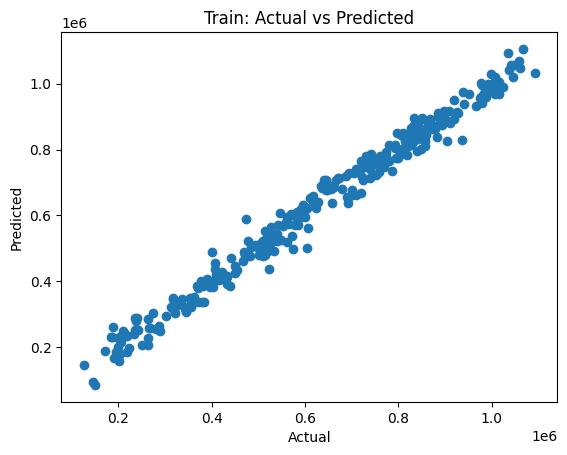

In [191]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Train: Actual vs Predicted")
plt.show()